# Browsers vs. Buyers: What Makes Online Shoppers Actually Buy?
**Patterns & Signals · Project 01**

12,330 visits to an online store over one year. Only some of them ended in a purchase.
**What separates the people who buy from the people who just look?**

> 📘 **How to read this notebook:** grey boxes are code; text boxes like this explain what the code does and why.
> Run a code box by clicking it and pressing **Shift + Enter**.

## 1. Load the tools
`pandas` works with tables of data (like Excel, but in code). `matplotlib` draws charts.
We give them short nicknames (`pd`, `plt`) so we type less.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Chart style used throughout (one blue for data, grey for supporting text)
BLUE, GREY, INK = "#2a78d6", "#8a8984", "#0b0b0b"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": GREY, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 11, "axes.titlesize": 14,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
})

## 2. Load the data
Each **row** is one visit (a "session"). Each **column** describes something about that visit.
The key column is **`Revenue`**: `True` if the visitor bought something, `False` if not.

In [2]:
df = pd.read_csv("data/online_shoppers_intention.csv")
print(f"{len(df):,} visits, {df.shape[1]} columns")
df.head()

12,330 visits, 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### What the main columns mean
| Column | Meaning |
|---|---|
| `ProductRelated` | How many product pages the visitor looked at |
| `BounceRates` | How often people leave after seeing just one page (when they land on these pages) |
| `PageValues` | How valuable the pages they saw are, based on whether those pages usually lead to sales |
| `SpecialDay` | How close the visit was to a holiday like Valentine's or Mother's Day (1 = right before it) |
| `VisitorType` | New or returning visitor |
| `Month`, `Weekend` | When the visit happened |
| `Revenue` | **Did they buy?** |

## 3. Check data quality
Before analysing anything, a good analyst checks for **missing values** and **duplicate rows**.

In [3]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 125


There are no missing values. There are 125 duplicate rows, but these are mostly very short visits
(one page, zero seconds) that look the same simply because they're so simple, so they are probably
different real visitors. We **keep them** and note this decision. Writing down choices like this
is a sign of a careful analyst.

## 4. The big picture: how many visitors buy?
Because `Revenue` is True/False, its average is the **share of visits that ended in a purchase**,
called the **conversion rate**.

In [4]:
overall = df["Revenue"].mean()
print(f"Conversion rate: {overall:.1%}")

Conversion rate: 15.5%


**About 1 in 6 visits (15.5%) ends in a purchase.** That's our baseline: everything below compares groups against it.

A helper function saves us from repeating the same chart code. It takes a group and draws its conversion rate as bars.

In [5]:
def conversion_chart(table, title, subtitle, xlabel, filename, highlight=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors = [BLUE if (highlight is None or lbl in highlight) else "#b9d3f2" for lbl in table.index]
    bars = ax.bar(table.index.astype(str), table["rate"] * 100, color=colors, width=0.62)
    ax.bar_label(bars, labels=[f"{v:.0%}" for v in table["rate"]], padding=3, color=INK, fontsize=10)
    ax.axhline(overall * 100, color=GREY, linestyle="--", linewidth=1)
    ax.set_ylim(0, table["rate"].max() * 100 * 1.15)
    ax.set_ylabel("Visits that bought (%)")
    ax.set_xlabel(xlabel)
    ax.set_title(title, pad=24)
    ax.text(0, 1.02, f"{subtitle}  ·  dashed line = average ({overall:.0%})", transform=ax.transAxes, color="#52514e", fontsize=10)
    ax.tick_params(axis="both", length=0)
    fig.tight_layout()
    fig.savefig(f"images/{filename}", dpi=160)
    plt.show()

def rate_by(column):
    # For each group: the share who bought, and how many visits were in the group
    return df.groupby(column, observed=True)["Revenue"].agg(rate="mean", visits="size")

## 5. Signal #1: what people look at matters most
`PageValues` measures whether a visitor viewed pages that usually come right before a purchase,
such as product details, the cart or checkout. We group visitors into bands of page value.

In [6]:
df["PageValueBand"] = pd.cut(df["PageValues"], bins=[-1, 0, 10, 50, float("inf")],
                             labels=["None", "Low (0–10)", "Medium (10–50)", "High (50+)"])
pv = rate_by("PageValueBand")
pv

,rate,visits
PageValueBand,,
None,0.038542,9600
Low (0–10),0.383621,928
Medium (10–50),0.610473,1394
High (50+),0.811275,408


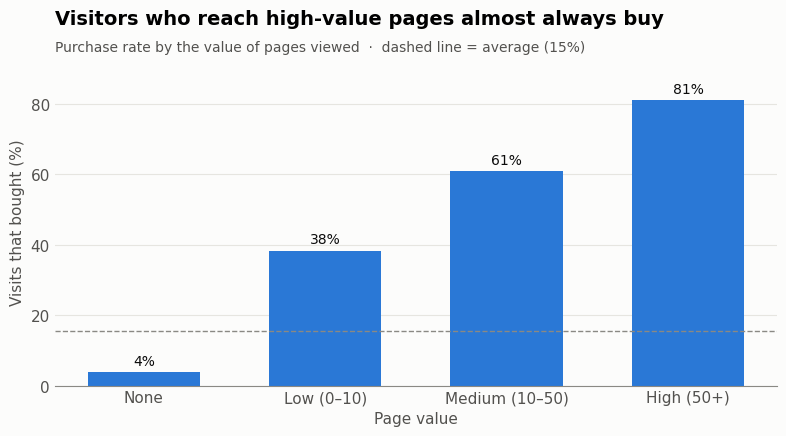

In [7]:
conversion_chart(pv, "Visitors who reach high-value pages almost always buy",
                 "Purchase rate by the value of pages viewed", "Page value", "01_page_value.png")

> 💡 **Insight:** Visitors who never reach a "valuable" page buy only **4%** of the time. Those who do
> reach high-value pages buy **81%** of the time. This is the strongest pattern in the data.
>
> **Why it matters:** the job isn't just getting people to the site, it's getting them **to the right pages**.
> Product recommendations, clear navigation and "add to cart" prompts lead people there.

## 6. Signal #2: first impressions (bounce rate)

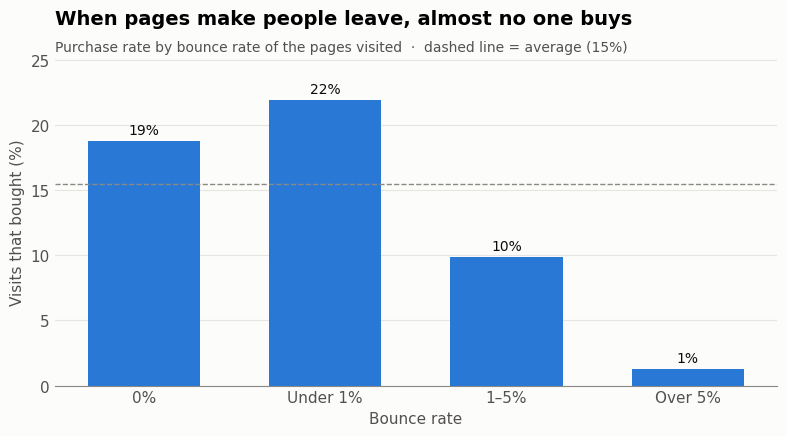

,rate,visits
BounceBand,,
0%,0.187749,5518
Under 1%,0.219051,2593
1–5%,0.098863,2903
Over 5%,0.012918,1316


In [8]:
df["BounceBand"] = pd.cut(df["BounceRates"], bins=[-1, 0, 0.01, 0.05, 1],
                          labels=["0%", "Under 1%", "1–5%", "Over 5%"])
br = rate_by("BounceBand")
conversion_chart(br, "When pages make people leave, almost no one buys",
                 "Purchase rate by bounce rate of the pages visited", "Bounce rate", "02_bounce.png")
br

> 💡 **Insight:** Visits on pages with high bounce rates (over 5%) convert at only **1%**.
> Pages that drive people away right away are a dead end for sales.

## 7. Signal #3: new visitors buy more than returning ones

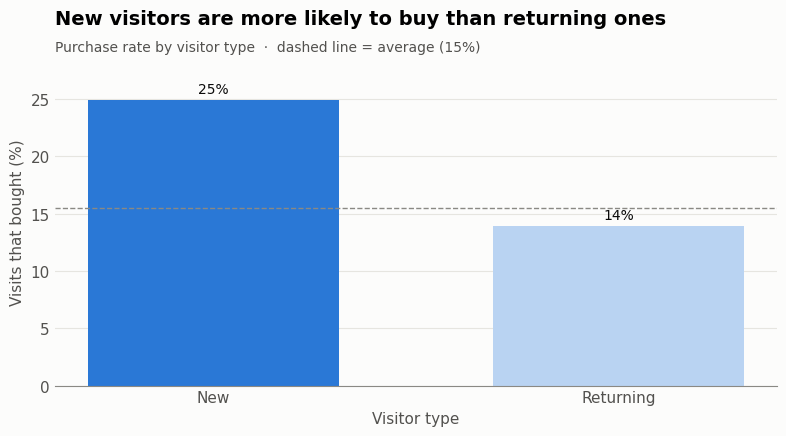

,rate,visits
VisitorType,,
New,0.249115,1694
Returning,0.139323,10551


In [9]:
vt = rate_by("VisitorType").rename(index={"New_Visitor": "New", "Returning_Visitor": "Returning"}).drop("Other")
conversion_chart(vt, "New visitors are more likely to buy than returning ones",
                 "Purchase rate by visitor type", "Visitor type", "03_visitor_type.png", highlight=["New"])
vt

> 💡 **Insight:** This is surprising: **25%** of new visitors buy, compared with **14%** of returning visitors.
>
> **A likely human explanation:** many returning visitors are *researching*. They come back to compare,
> check prices, or think it over. New visitors often arrive with a specific goal (from an ad or search) and act on it.
> For a business, returning visitors may need a nudge, such as a reminder of what's in their cart or a time-limited offer.

## 8. Signal #4: timing. Holidays make people browse, not buy

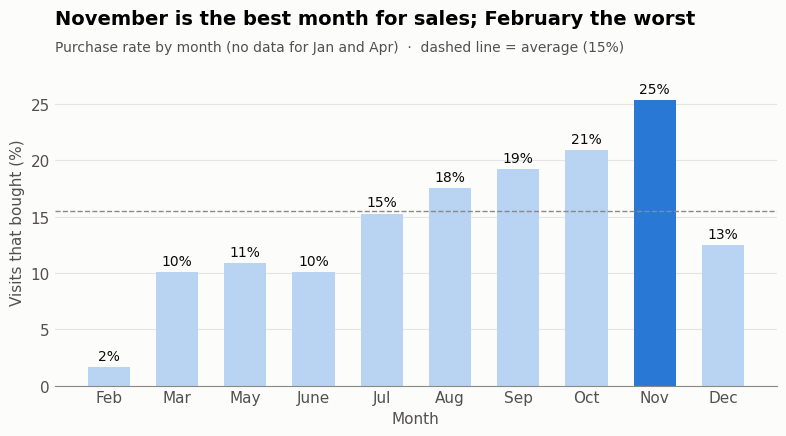

,rate,visits
Month,,
Feb,0.016304,184
Mar,0.100682,1907
May,0.108502,3364
June,0.100694,288
Jul,0.152778,432
Aug,0.175520,433
Sep,0.191964,448
Oct,0.209472,549
Nov,0.253502,2998


In [10]:
months = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
mo = rate_by("Month").reindex(months)
conversion_chart(mo, "November is the best month for sales; February the worst",
                 "Purchase rate by month (no data for Jan and Apr)", "Month", "04_month.png", highlight=["Nov"])
mo

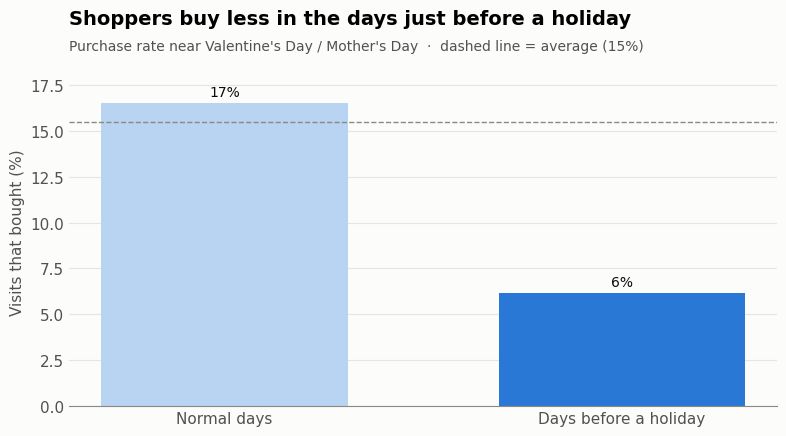

,rate,visits
NearHoliday,,
Normal days,0.165268,11079
Days before a holiday,0.061551,1251


In [11]:
df["NearHoliday"] = df["SpecialDay"].gt(0).map({True: "Days before a holiday", False: "Normal days"})
sd = rate_by("NearHoliday").reindex(["Normal days", "Days before a holiday"])
conversion_chart(sd, "Shoppers buy less in the days just before a holiday",
                 "Purchase rate near Valentine's Day / Mother's Day", "", "05_holiday.png", highlight=["Days before a holiday"])
sd

> 💡 **Insight:** November (the run-up to Black Friday and the holiday season) converts at **25%**, while visits in the
> days just before Valentine's or Mother's Day convert at only about **6%**, well below normal days (**17%**).
>
> **A likely human explanation:** before a gift-giving holiday, people **browse for ideas** and compare options, but many
> buy elsewhere or at the last minute. In November people are in a deliberate "deal-hunting" mindset and come ready to buy.

## 9. Export a clean file for Tableau
We save the data with our new columns (the bands we created) so we can build an interactive dashboard in Tableau.

In [12]:
df["Purchased"] = df["Revenue"].map({True: "Bought", False: "Didn't buy"})
df.to_csv("data/online_shoppers_tableau.csv", index=False)
print("Saved data/online_shoppers_tableau.csv")

Saved data/online_shoppers_tableau.csv


## 10. Summary
| # | Signal | Finding |
|---|---|---|
| 1 | **Pages viewed** | Reaching high-value pages: 81% buy. Never reaching them: 4% |
| 2 | **Bounce rate** | Pages that drive people away convert at 1% |
| 3 | **Visitor type** | New visitors buy more often (25%) than returning ones (14%) |
| 4 | **Timing** | November peaks (25%). The days just before gift holidays dip (about 6%) |

**Recommendations for the business**
1. Guide visitors to product and cart pages quickly with recommendations, clear navigation and visible "add to cart" buttons.
2. Fix or redesign the pages people leave most often.
3. Give returning visitors a reason to decide now, such as saved-cart reminders or limited-time offers.
4. Before gift holidays, help browsers become buyers with gift guides and delivery-by-date promises.

**Limitations:** this data comes from one store over one year, and it shows *patterns*, not *causes*. For example,
high page value goes together with buying, but that doesn't prove the pages *cause* the purchase.

*Data: Sakar, C.O., Polat, S.O., Katircioglu, M. & Kastro, Y. (2019). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository.*